# IF25-40305: Sistem Teknologi Multimedia (STM)
## Tugas 2 — Analisis Sinyal Suara & Noise Statis

**Nama  :** Muhammad Romadhon S

**NIM   :** 123140031

---

### 📋 Ringkasan Tugas
Notebook ini menganalisis rekaman suara berita yang dibacakan sendiri di depan sumber **noise statis**
(kipas angin / AC / pompa air), mencakup:
1. Akuisisi audio & ekstraksi metadata
2. Visualisasi audio 4 dimensi: **Waveform, Spektrum FFT (dBFS), Spektrogram STFT, Mel-Spektrogram**
3. Eksperimen resampling & pembuktian **aliasing** (Naive Decimation vs Resampling Standar DSP)



## 1. Import Library & Persiapan Lingkungan

- `numpy` — komputasi numerik & array sinyal
- `matplotlib.pyplot` — visualisasi waveform, spektrum, spektrogram
- `scipy.signal` — `get_window` (windowing FFT), `resample_poly` (resampling berfilter anti-aliasing), `find_peaks` (deteksi puncak frekuensi)
- `librosa`, `librosa.display` — loading audio, STFT, Mel-spectrogram, resampling standar industri
- `soundfile` — menyimpan berkas `.wav` hasil eksperimen resampling
- `IPython.display` — pemutar audio interaktif di dalam notebook


In [9]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window, resample_poly, find_peaks
import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd
from IPython.display import display

# Konfigurasi visualisasi (konsisten dengan gaya Hands-on 1 & 2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

# Palet warna konsisten dipakai ulang di seluruh notebook agar tiap konsep
# selalu diwakili warna yang sama pada setiap gambar.
C_SIGNAL = '#0284c7'   # biru   - bagian vokal aktif / sinyal utama
C_NOISE  = '#dc2626'   # merah  - bagian hening (noise statis saja)
C_GOOD   = '#059669'   # hijau  - hasil bersih (resampling berfilter)
C_ALERT  = '#dc2626'   # merah  - hasil rusak (aliasing)
C_ACCENT = '#7c3aed'   # violet - penekanan sekunder
C_GOLD   = '#c5a059'   # emas   - panel Mel-spektrogram

print(f"numpy     : {np.__version__}")
print(f"librosa   : {librosa.__version__}")
print(f"soundfile : {sf.__version__}")
print("\n✅ Seluruh pustaka DSP dan audio berhasil dimuat!")


numpy     : 2.5.3
librosa   : 1.0.0
soundfile : 0.14.0

✅ Seluruh pustaka DSP dan audio berhasil dimuat!


## 2. Akuisisi Audio & Ekstraksi Metadata

### 🎙️ Detail Rekaman


Rekaman ini berdurasi kurang lebih 20 detik, dengan sumber noise statis menggunakan kipas angin. Alat perekam yang digunakan berupa handphone Xiaomi Redmi Note 10s dengan aplikasi voice recorder bawaan. Jarak dari alat perekem ke sumber noise sekitar 0.15 meter. Informasi yang direkam berupa berita https://otodriver.com/berita/2026/changan-nevo-q05-suv-listrik-yang-harganya-sudah-masuk-wilayah-lmpv-chaefdiempv 


In [10]:
AUDIO_PATH = "audio_original.wav"

if not os.path.exists(AUDIO_PATH):
    raise FileNotFoundError(
        f"Berkas '{AUDIO_PATH}' tidak ditemukan!\n"
        "Pastikan hasil rekamanmu (.wav) sudah diletakkan satu folder dengan notebook ini,\n"
        "dan namanya persis 'audio_original.wav'."
    )

# sr=None -> PENTING: pertahankan laju sampel ASLI rekaman.
# Jika sr diisi angka lain, librosa akan diam-diam meresample saat loading,
# sehingga metadata "laju sampel asli" yang kita cetak jadi tidak jujur.
y, sr = librosa.load(AUDIO_PATH, sr=None, mono=True)
t = np.arange(len(y)) / sr
durasi = len(y) / sr

print("=== METADATA REKAMAN ===")
print(f"Berkas             : {AUDIO_PATH}")
print(f"Laju sampel asli   : {sr} Hz")
print(f"Jumlah sampel      : {len(y)} sampel")
print(f"Durasi             : {durasi:.2f} detik")
print(f"Amplitudo minimum  : {y.min():.4f}")
print(f"Amplitudo maksimum : {y.max():.4f}")
print(f"Puncak absolut     : {np.max(np.abs(y)):.4f}  "
      f"({20*np.log10(np.max(np.abs(y)) + 1e-12):.2f} dBFS)")

display(ipd.Audio(y, rate=sr))


=== METADATA REKAMAN ===
Berkas             : audio_original.wav
Laju sampel asli   : 48000 Hz
Jumlah sampel      : 1113600 sampel
Durasi             : 23.20 detik
Amplitudo minimum  : -0.4606
Amplitudo maksimum : 0.5250
Puncak absolut     : 0.5250  (-5.60 dBFS)


### ✍️ Analisis Kamu — Akuisisi & Metadata
Jawab dengan kalimatmu sendiri (2–4 kalimat), mengacu pada angka hasil sel di atas:
- Apakah durasi rekamanmu berada di rentang 10–20 detik sesuai ketentuan?
- Apakah laju sampel aslinya sesuai standar (mis. 44100 Hz atau 48000 Hz)? Dari mana kamu tahu?
- Apakah nilai puncak amplitudo mendekati ±1.0 (indikasi clipping/kepenuhan volume) atau justru
  terlalu kecil (indikasi rekaman terlalu pelan)?

`<Tulis analisismu di sini>`


## 3. Visualisasi Audio 4 Dimensi

### 3a. Waveform (Amplitudo vs Waktu)


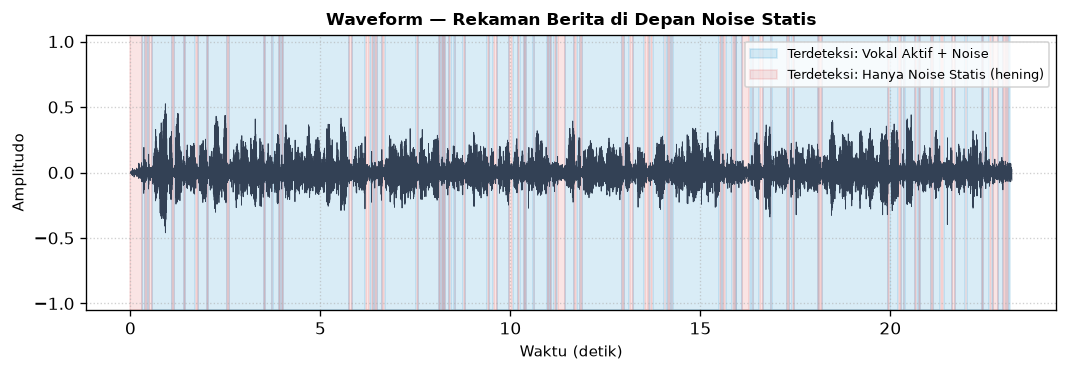

Ambang energi (threshold) : 3.9 dB
Proporsi durasi 'aktif'   : 82.9%
Proporsi durasi 'hening'  : 17.1%


In [11]:
# Hitung energi jangka pendek (short-time energy) per jendela 50 ms, geser 10 ms
frame_len = int(0.05 * sr)
hop_len   = int(0.01 * sr)

energy = np.array([
    np.sum(y[i:i + frame_len] ** 2)
    for i in range(0, len(y) - frame_len, hop_len)
])
energy_db = 10 * np.log10(energy + 1e-12)
t_energy = np.arange(len(energy)) * hop_len / sr

# Ambang batas otomatis: titik tengah antara energi minimum & maksimum (dalam dB)
threshold_db = (energy_db.max() + energy_db.min()) / 2
is_active = energy_db > threshold_db   # True = terdeteksi vokal aktif, False = hening (noise saja)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t, y, color='#334155', lw=0.5)

# Sorot rentang waktu yang terdeteksi aktif (vokal+noise) vs hening (noise statis saja)
ax.fill_between(t_energy, -1.05, 1.05, where=is_active, color=C_SIGNAL, alpha=0.15,
                 step='post', label='Terdeteksi: Vokal Aktif + Noise')
ax.fill_between(t_energy, -1.05, 1.05, where=~is_active, color=C_NOISE, alpha=0.12,
                 step='post', label='Terdeteksi: Hanya Noise Statis (hening)')

ax.set_title("Waveform — Rekaman Berita di Depan Noise Statis", fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Amplitudo", fontsize=9)
ax.set_ylim(-1.05, 1.05)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Ambang energi (threshold) : {threshold_db:.1f} dB")
print(f"Proporsi durasi 'aktif'   : {100*np.mean(is_active):.1f}%")
print(f"Proporsi durasi 'hening'  : {100*np.mean(~is_active):.1f}%")


### ✍️ Analisis Visualisasi 1: Waveform (Amplitudo vs Waktu)

Berdasarkan grafik **Waveform — Rekaman Berita di Depan Noise Statis** di atas, gelombang audio direpresentasikan dalam kurun waktu selama **23,20 detik** (sumbu X) terhadap **Amplitudo** pada rentang **-1.0 hingga 1.0** (sumbu Y). Secara visual, terbagi menjadi dua area deteksi, yaitu area berwarna **biru muda** yang menandakan segmen **Vokal Aktif + Noise**, serta area garis-garis vertikal berwarna **merah muda** yang menandakan segmen **Hanya Noise Statis (hening)** ketika jeda berbicara.

Perbedaan karakteristik antara bagian hening (*noise floor*) dan bagian vokal aktif pada grafik tersebut dapat dijelaskan melalui poin-poin berikut:

* **Karakteristik Bagian Hening / Noise Statis (Latar Merah Muda):**
  Pada bagian awal rekaman di detik ke-0 hingga 0,5, bagian akhir rekaman pada detik ke-22,5 hingga 23,2, serta sela-sela jeda singkat antar kalimat seperti di sekitar detik ke-6, 11,3, dan 16. Namun, gelombang hitam di tengah grafik terlihat **tidak menyempit menjadi garis lurus bernilai 0.0**, melainkan tetap memiliki ketebalan gelombang yang konstan di kisaran amplitudo **±0,05 hingga ±0,08**. Ketebalan ini merupakan wujud dari *noise floor* statis (suara derau konstan dari sumber noise) yang terus masuk ke mikrofon.
* **Karakteristik Bagian Vokal Aktif (Latar Biru Muda):**
  Ketika mulai membacakan teks berita, simpangan gelombang hitam langsung melonjak tinggi dan melebar secara fluktuatif mengikuti intonasi pengucapan suku kata. Lonjakan amplitudo vokal ini rata-rata berada di kisaran **-0,3 hingga 0,4**, dengan titik simpangan tertinggi mencapai **0,5250** dan simpangan bawah mencapai **-0,4606** pada detik ke-1 awal pembacaan berita.
* **Membedakan Vokal dan Noise di Domain Waktu:**
  Bagian vokal aktif dan bagian hening dapat dibedakan langsung dari **tinggi simpangan (amplitudo) dan pola fluktuasinya**. Bagian *noise* statis memiliki amplitudo yang kecil dan ketebalannya cenderung stabil, sedangkan bagian vokal aktif memiliki lonjakan-lonjakan puncak gelombang yang jauh lebih tinggi, tajam, dan berubah-ubah sesuai ritme bicara. Selain itu, puncak gelombang tertinggi pda 0,5250 masih berada jauh di bawah batas maksimum grafik, yang berarti suara terekam dengan jelas tanpa menjadi pecah akibat terlalu keras.

### 3b. Spektrum FFT (dBFS Terkalibrasi)


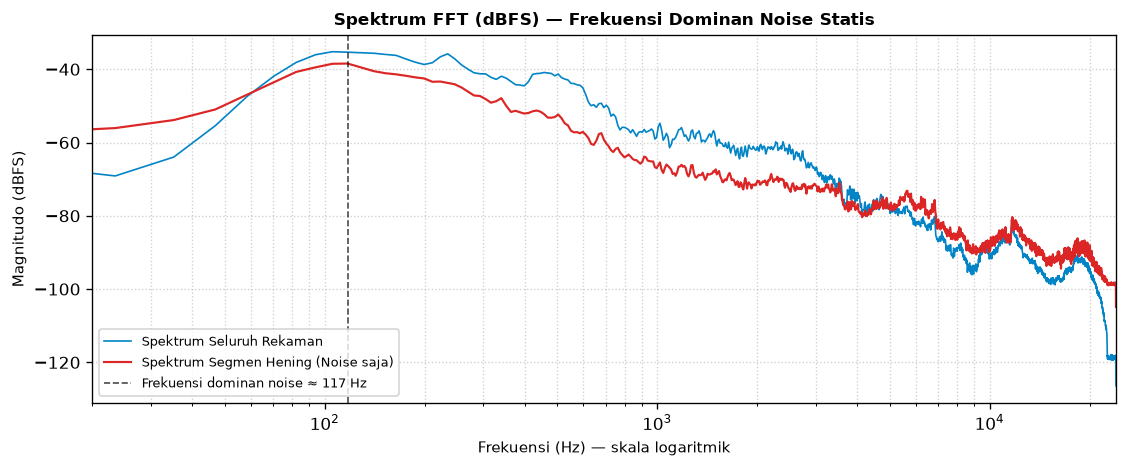

Frekuensi dominan noise statis (segmen hening) : ≈ 117 Hz


In [12]:
def spectrum_dbfs(x, sr, n_fft=4096, average=True):
    """Menghitung spektrum satu sisi berskala dBFS yang terkalibrasi.
    (Diadaptasi dari Hands-on 2: 2_audio_visual_representation.ipynb)

    Mengembalikan (frekuensi_hz, magnitudo_dbfs).
    """
    x = np.asarray(x, dtype=float)
    if len(x) < n_fft:
        x = np.pad(x, (0, n_fft - len(x)))

    w = get_window('hann', n_fft, fftbins=True)
    hop = n_fft // 2
    n_frames = 1 + (len(x) - n_fft) // hop if average else 1

    akumulasi = np.zeros(n_fft // 2 + 1)
    for i in range(n_frames):
        seg = x[i * hop: i * hop + n_fft]
        akumulasi += np.abs(np.fft.rfft(seg * w))
    mag = akumulasi / n_frames / np.sum(w)
    mag[1:-1] *= 2.0   # koreksi spektrum satu sisi (tidak berlaku untuk bin DC & Nyquist)

    db = 20 * np.log10(np.maximum(mag, 1e-12))
    freqs = np.fft.rfftfreq(n_fft, 1 / sr)
    return freqs, db


# Ambil sampel-sampel yang termasuk segmen HENING (noise statis murni) berdasarkan
# hasil deteksi energi di bagian 3a, lalu petakan balik ke resolusi per-sampel.
noise_mask_samples = np.repeat(~is_active, hop_len)[:len(y)]
noise_mask_samples = np.repeat(~is_active, hop_len)[:len(y)]

# Buat mask per-sampel agar panjangnya sama dengan sinyal utama
# setiap jendela 50 ms (frame_len) dengan hop 10 ms (hop_len) dipetakan ke sampel-sampelnya
noise_mask_samples = np.zeros(len(y), dtype=bool)

for i, is_noise in enumerate(~is_active):
    start = i * hop_len
    stop = min(start + frame_len, len(y))
    noise_mask_samples[start:stop] = is_noise

noise_only = y[noise_mask_samples]
freqs_noise, db_noise = spectrum_dbfs(noise_only, sr, n_fft=4096)
freqs_full,  db_full  = spectrum_dbfs(y, sr, n_fft=4096)

# Cari puncak tertinggi pada spektrum segmen hening -> itulah frekuensi dominan noise statis
peak_idx, _ = find_peaks(db_noise, height=db_noise.max() - 20)
f_dominan = (freqs_noise[peak_idx[np.argmax(db_noise[peak_idx])]]
             if len(peak_idx) else freqs_noise[np.argmax(db_noise)])

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.semilogx(freqs_full[1:], db_full[1:], color=C_SIGNAL, lw=1.0, label='Spektrum Seluruh Rekaman')
ax.semilogx(freqs_noise[1:], db_noise[1:], color=C_NOISE, lw=1.3, label='Spektrum Segmen Hening (Noise saja)')
ax.axvline(f_dominan, color='k', linestyle='--', lw=1.0, alpha=0.7,
           label=f'Frekuensi dominan noise ≈ {f_dominan:.0f} Hz')

ax.set_title("Spektrum FFT (dBFS) — Frekuensi Dominan Noise Statis", fontsize=10, fontweight='bold')
ax.set_xlabel("Frekuensi (Hz) — skala logaritmik", fontsize=9)
ax.set_ylabel("Magnitudo (dBFS)", fontsize=9)
ax.set_xlim(20, sr / 2)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Frekuensi dominan noise statis (segmen hening) : ≈ {f_dominan:.0f} Hz")


### ✍️ Analisis Visualisasi 2: Spektrum FFT (dBFS Terkalibrasi)

Berdasarkan grafik **Spektrum FFT (dBFS) — Frekuensi Dominan Noise Statis** di atas, sinyal audio telah diubah dari domain waktu ke domain frekuensi menggunakan *Fast Fourier Transform* (FFT). Sumbu mendatar (X) menampilkan **Frekuensi (Hz) dalam skala logaritmik** (mulai dari di bawah $10^2\text{ Hz}$ hingga batas Nyquist $24.000\text{ Hz}$), sedangkan sumbu tegak (Y) menampilkan kekuatan energi suara atau **Magnitudo dalam skala dBFS** ($20 \log_{10}$). Grafik ini membandingkan dua kurva utama, yaitu **Spektrum Seluruh Rekaman (garis biru)** yang mencakup suara vokal pembacaan berita beserta *noise*, dan **Spektrum Segmen Hening (garis merah)** yang hanya merepresentasikan *noise* statis saja.

Hasil identifikasi dan analisis perbandingan dari kedua kurva spektrum tersebut meliputi poin-poin berikut:

* **Frekuensi Dominan pada Derau / Noise Statis ($\approx 117\text{ Hz}$):**
  Berdasarkan hasil deteksi puncak pada kurva merah (ditandai oleh garis vertikal putus-putus), energi *noise* statis mencapai titik paling dominan pada frekuensi rendah sekitar **117 Hz** dengan magnitudo sekitar **-38 dBFS**. Hal ini menunjukkan bahwa sumber *noise* statis pada rekaman didominasi oleh suara dengungan frekuensi rendah (hembusan angin konstan dari kipas). Semakin ke kanan menuju frekuensi menengah dan tinggi (di atas $1.000\text{ Hz}$ hingga $20.000\text{ Hz}$), energi *noise* statis ini terus menurun secara bertahap dari **-65 dBFS** hingga menyentuh **-100 dBFS**.
* **Dominasi Suara Vokal pada Frekuensi Rendah–Menengah ($100\text{ Hz} - 3.500\text{ Hz}$):**
  Pada rentang frekuensi **$80\text{ Hz}$ hingga $3.500\text{ Hz}$**, kurva biru terlihat konsisten berada di atas kurva merah. Terdapat beberapa puncak menonjol pada kurva biru yang tidak dimiliki kurva merah, seperti puncak pada kisaran **110–120 Hz** (sekitar **-35 dBFS**), lonjakan kedua di sekitar **230 Hz** (**-35 dBFS**), lonjakan ketiga di sekitar **450 Hz** (**-41 dBFS**), serta selisih energi yang cukup lebar (sekitar 10–12 dB lebih tinggi) pada rentang **$1.000\text{ Hz}$ hingga $2.800\text{ Hz}$**. Rentang inilah yang merupakan wilayah frekuensi fundamental ($F_0$) dan harmonik vokal suara membacakan berita.
* **Karakteristik pada Frekuensi Tinggi ($> 3.500\text{ Hz}$):**
  Memasuki frekuensi di atas **$3.500\text{ Hz}$** (mendekati $10^4\text{ Hz}$ atau $10\text{ kHz}$ ke atas), kurva biru dan kurva merah mulai saling berhimpitan dengan magnitudo yang sangat lemah (di bawah **-75 dBFS** hingga **-120 dBFS**). Hal ini membuktikan bahwa suara ucapan manusia tidak banyak menyumbangkan energi pada frekuensi sangat tinggi, sehingga komponen frekuensi di atas $4\text{ kHz}$ pada rekaman ini praktis hanya didominasi oleh sisa desis dari *noise* statis.

### 3c. Spektrogram STFT


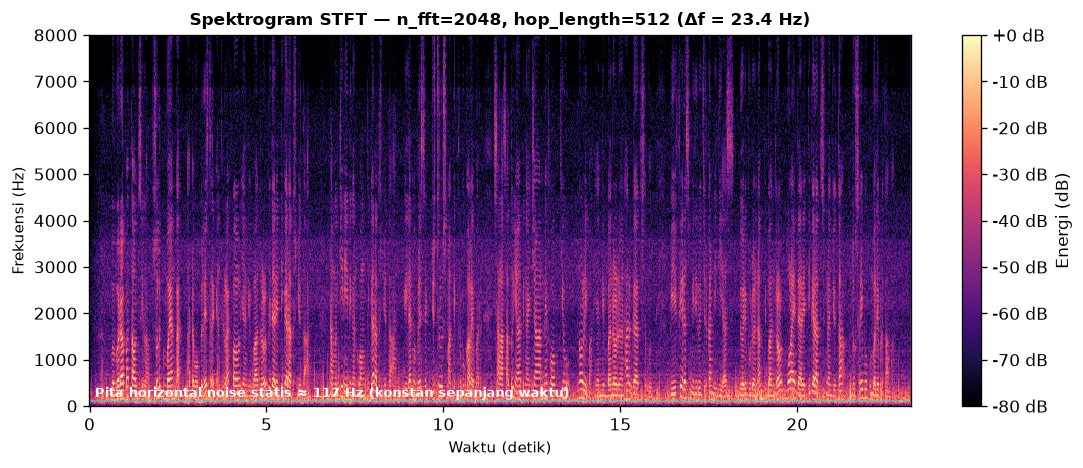

In [13]:
N_FFT, HOP = 2048, 512

S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))
S_db = librosa.amplitude_to_db(S, ref=np.max)

fig, ax = plt.subplots(figsize=(9.5, 4))
img = librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                                x_axis='time', y_axis='linear', ax=ax, cmap='magma')
ax.set_ylim(0, min(8000, sr / 2))

# Tandai garis horizontal frekuensi dominan noise statis (dari bagian 3b)
ax.axhline(f_dominan, color='#22d3ee', lw=1.0, linestyle='--', alpha=0.9)
ax.text(0.15, f_dominan + 80, f"Pita horizontal noise statis ≈ {f_dominan:.0f} Hz (konstan sepanjang waktu)",
        color='white', fontsize=8, fontweight='bold')

ax.set_title(f"Spektrogram STFT — n_fft={N_FFT}, hop_length={HOP} (Δf = {sr/N_FFT:.1f} Hz)",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Waktu (detik)", fontsize=9)
ax.set_ylabel("Frekuensi (Hz)", fontsize=9)
fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Energi (dB)')
plt.tight_layout()
plt.show()


### ✍️ Analisis Visualisasi 3: Spektrogram STFT

Berdasarkan grafik **Spektrogram STFT (`n_fft=2048`, `hop_length=512`, $\Delta f = 23,4\text{ Hz}$)** di atas, sinyal audio direpresentasikan ke dalam domain waktu dan frekuensi secara bersamaan. Sumbu X menunjukkan perjalanan **Waktu (detik)** hingga 23,20 detik, sumbu Y menunjukkan **Frekuensi (Hz)** dalam skala linear dari 0 hingga 8.000 Hz, dan tingkat kecerahan warna merepresentasikan **Energi (dB)** (dari hitam pekat pada -80 dB hingga kuning terang mendekati 0 dB). Penggunaan ukuran jendela FFT sebesar 2048 sampel pada laju sampel 48.000 Hz menghasilkan resolusi frekuensi sebesar $\Delta f = \frac{48.000}{2048} \approx 23,4\text{ Hz}$, sehingga struktur harmonik vokal dan letak frekuensi *noise* dapat terpetakan dengan tajam.

Karakteristik pola *noise* statis dan vokal pembacaan berita pada spektrogram STFT tersebut dapat dianalisis melalui poin-poin berikut:

* **Jejak Pita Horizontal Konstan pada Noise Statis ($\approx 117\text{ Hz}$):**
  Keberadaan *noise* statis terlihat pada bagian dasar spektrogram (di sekitar frekuensi **117 Hz**, tepat pada garis penunjuk di bagian bawah), di mana terdapat **pita garis horizontal berwarna oranye terang (sekitar -30 dB hingga -20 dB) yang menyala terus-menerus** sejak detik ke-0 hingga detik ke-23,20. Selain pita utama di 117 Hz tersebut, *noise* statis juga membentuk latar belakang berwarna ungu konstan (sekitar -65 dB hingga -50 dB) yang merata pada pita frekuensi **0–3.700 Hz** dan menipis hingga sekitar **6.800 Hz**. Pola horizontal yang statis ini membuktikan bahwa sumber derau memiliki kandungan frekuensi yang tetap terhadap waktu, bahkan pada celah waktu saat vokal berhenti.
* **Pola Harmonik dan Transien pada Vokal Aktif:**
  Berbeda dengan *noise* yang berbentuk pita horizontal rata, suara pembacaan berita muncul pada struktur vertikal yang terputus-putus mengikuti ritme pengucapan kata. Pada rentang frekuensi rendah–menengah (**100 Hz hingga 3.000 Hz**), energi vokal tampak menyala terang (oranye hingga kuning) dengan pola garis-garis bertumpuk yang merupakan **frekuensi fundamental ($F_0$) beserta kelipatan harmonik** dari suara vokal.
* **Identifikasi Konsonan Desis (*Sibilance*) di Frekuensi Tinggi:**
  Pada beberapa titik waktu tertentu seperti pada detik ke-1,2, detik ke-11,5, dan paling jelas pada detik ke-18, terlihat garis vertikal berwarna ungu oranye yang menjulang tinggi pda frekuensi **4.000 Hz hingga 7.500 Hz**. Semburan energi frekuensi tinggi yang singkat ini bukan berasal dari *noise* statis, melainkan dari pengucapan yang menghasilkan desis (seperti huruf *"s"*, *"sy"*, atau *"c"*) ketika membaca teks berita.

### 3d. Mel-Spektrogram


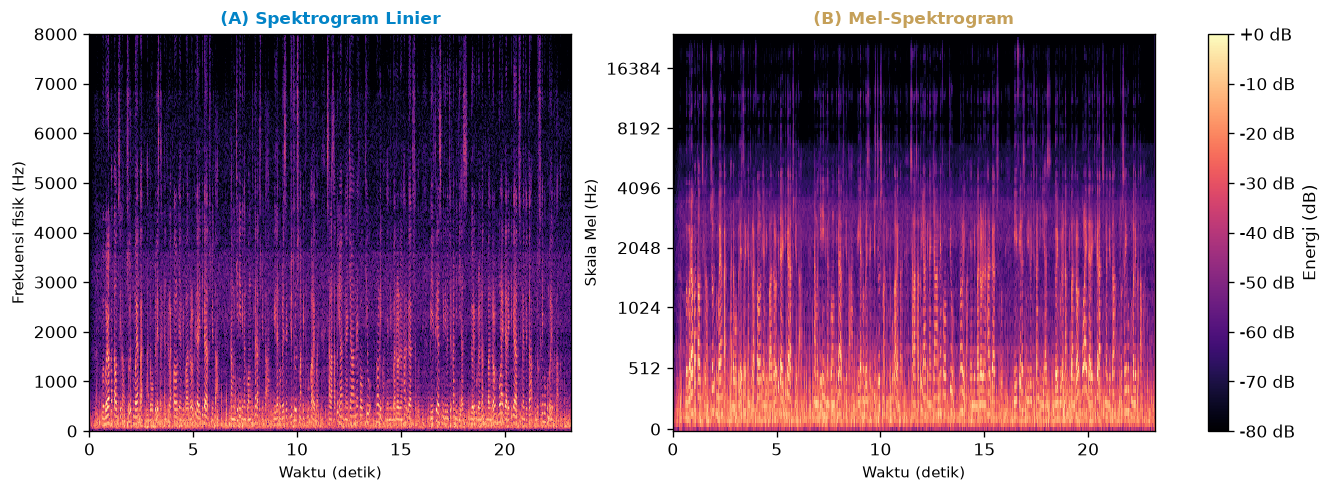

Dimensi spektrogram linier : 1025 bin frekuensi × 2176 bingkai waktu
Dimensi Mel-spektrogram    :  128 bin Mel       × 2176 bingkai waktu


In [14]:
N_MELS = 128

S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

librosa.display.specshow(S_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                          x_axis='time', y_axis='linear', ax=axes[0], cmap='magma')
axes[0].set_ylim(0, min(8000, sr / 2))
axes[0].set_title("(A) Spektrogram Linier", fontsize=10, fontweight='bold', color=C_SIGNAL)
axes[0].set_ylabel("Frekuensi fisik (Hz)", fontsize=9)

img = librosa.display.specshow(S_mel_db, sr=sr, hop_length=HOP, n_fft=N_FFT,
                                x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
axes[1].set_title("(B) Mel-Spektrogram", fontsize=10, fontweight='bold', color=C_GOLD)
axes[1].set_ylabel("Skala Mel (Hz)", fontsize=9)

for ax in axes:
    ax.set_xlabel("Waktu (detik)", fontsize=9)
fig.colorbar(img, ax=axes, format='%+2.0f dB', label='Energi (dB)')
plt.show()

print(f"Dimensi spektrogram linier : {S_db.shape[0]:>4} bin frekuensi × {S_db.shape[1]} bingkai waktu")
print(f"Dimensi Mel-spektrogram    : {S_mel_db.shape[0]:>4} bin Mel       × {S_mel_db.shape[1]} bingkai waktu")


### ✍️ Analisis Visualisasi 4: Perbandingan Spektrogram Linier vs Mel-Spektrogram

Berdasarkan grafik komparasi **(A) Spektrogram Linier** dan **(B) Mel-Spektrogram** di atas, sinyal rekaman yang sama ditampilkan menggunakan dua pemetaan sumbu frekuensi yang berbeda. Pada panel (A), sumbu Y menggunakan **Frekuensi Fisik (Hz) berskala linier** (`0` hingga `8000 Hz` dengan kenaikan tetap per `1000 Hz`), sedangkan pada panel (B), sumbu Y telah dikonversi menggunakan *filterbank* ke dalam **Skala Mel (Hz)** yang bersifat logaritmik (`0, 512, 1024, 2048, 4096, 8192, 16384 Hz`) untuk meniru persepsi pendengaran telinga manusia.

Alasan mengapa vokal manusia terlihat jauh lebih padat dan jelas pada Mel-Spektrogram dibandingkan Spektrogram Linier dapat dijelaskan melalui poin-poin analisis berikut:

* **Proporsi Ruang Visual pada Frekuensi Rendah–Menengah (`0 - 2048 Hz`):**
  Pada **(A) Spektrogram Linier**, rentang frekuensi `0 – 1000 Hz` yang dimana tempat berkumpulnya frekuensi dasar $F_0$ dan vokal manusia hanya menempati **seperdelapan (12,5%)** bagian paling bawah dari tinggi grafik, sementara sebagian besar ruang grafik di atas `3000 Hz` habis dipakai oleh area gelap berenergi rendah. Sebaliknya, pada **(B) Mel-Spektrogram**, rentang frekuensi `0 – 1024 Hz` diregangkan hingga menempati hampir **40% bagian bawah grafik**, dan rentang hingga `2048 Hz` mencakup lebih dari separuh tinggi grafik. Peregangan visual inilah yang membuat warna kuning oranye dari energi vokal manusia tampak jauh lebih mekar.
* **Kejelasan Struktur Vokal sesuai Persepsi Telinga Manusia:**
  Sistem pendengaran manusia memiliki resolusi yang sangat sensitif terhadap perubahan frekuensi rendah hingga menengah, namun semakin kurang sensitif dalam membedakan detail di frekuensi tinggi. Karena karakter huruf vokal dan artikulasi bicara manusia ditentukan oleh pita resonansi yang berada di rentang **300 Hz hingga 3.500 Hz**, pemetaan Skala Mel secara efektif memperbesar wilayah frekuensi vokal tersebut. Hasilnya, alur naik-turunnya intonasi serta kepadatan energi pada setiap kata berita yang diucapkan terlihat jauh lebih tegas pada panel (B) dibandingkan panel (A) yang tampak tergencet di dasar sumbu.
* **Pemampatan Frekuensi Tinggi dan Kenampakan Noise Latar:**
  Pada frekuensi tinggi di atas `4096 Hz`, Skala Mel memampatkan rentang frekuensi yang sangat lebar (`4096 – 16384 Hz`) ke dalam ruang vertikal yang ringkas di bagian atas grafik. Pada panel (B), batas *noise* statis di sekitar `3700 – 4096 Hz` masih terlihat jelas sebagai batas gradasi warna ungu, ditambah terlihatnya sedikit sisa desis frekuensi sangat tinggi di sekitar `8192 – 16384 Hz` yang terkompresi tanpa mengambil ruang visual frekuensi vokal utama.

## 4. Eksperimen Resampling & Pembuktian Aliasing

Laju sampel target dipilih otomatis mengikuti laju sampel asli rekamanmu, agar hasil desimasi
tepat bulat (tanpa sisa):
- Asli 44.100 Hz → target **11.025 Hz** (faktor $M = 4$)
- Asli 48.000 Hz → target **8.000 Hz** (faktor $M = 6$)
- Laju sampel lain → $M$ dibulatkan otomatis agar target mendekati 8.000 Hz


In [15]:
sr_orig = sr

if abs(sr_orig - 44100) < 1:
    M = 4                                  # -> target 11.025 Hz (pembagi bulat persis)
elif abs(sr_orig - 48000) < 1:
    M = 6                                  # -> target 8.000 Hz (pembagi bulat persis)
else:
    M = max(1, round(sr_orig / 8000))      # fallback umum: target mendekati 8 kHz

fs_target = sr_orig // M

print(f"Laju sampel asli   : {sr_orig} Hz")
print(f"Faktor desimasi M  : {M}")
print(f"Laju sampel target : {fs_target} Hz  (Batas Nyquist baru = {fs_target/2:.0f} Hz)")


Laju sampel asli   : 48000 Hz
Faktor desimasi M  : 6
Laju sampel target : 8000 Hz  (Batas Nyquist baru = 4000 Hz)


In [16]:
# Skenario A: Naive Decimation — ambil tiap sampel ke-M, TANPA filter anti-aliasing
y_naive = y[::M]

# Skenario B: Resampling standar DSP — Polyphase FIR dengan filter anti-aliasing bawaan
y_clean = resample_poly(y, up=1, down=M)

print(f"Skenario A (Naive Decimation)     : {len(y_naive)} sampel @ {fs_target} Hz")
print(f"Skenario B (resample_poly, anti-aliasing) : {len(y_clean)} sampel @ {fs_target} Hz")

# Simpan kedua hasil sebagai berkas .wav — WAJIB ikut di-commit ke folder repo
sf.write("audio_downsampled_naive.wav", y_naive, fs_target)
sf.write("audio_downsampled_clean.wav", y_clean, fs_target)
print("\n✅ 'audio_downsampled_naive.wav' dan 'audio_downsampled_clean.wav' berhasil disimpan.")


Skenario A (Naive Decimation)     : 185600 sampel @ 8000 Hz
Skenario B (resample_poly, anti-aliasing) : 185600 sampel @ 8000 Hz

✅ 'audio_downsampled_naive.wav' dan 'audio_downsampled_clean.wav' berhasil disimpan.


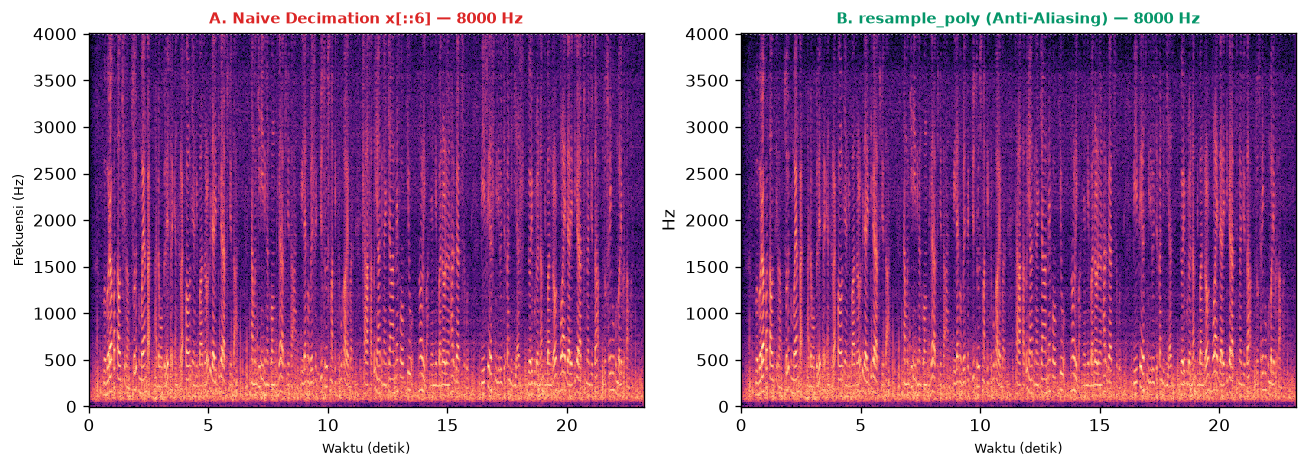

1. 🎵 Hasil Naive Decimation (dengarkan, perhatikan bila ada bunyi aneh/berdengung tajam):


2. 🎵 Hasil resample_poly / Standar DSP (dengarkan sebagai pembanding):


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, sinyal, judul, warna in (
    (axes[0], y_naive, f"A. Naive Decimation x[::{M}] — {fs_target} Hz", C_ALERT),
    (axes[1], y_clean, f"B. resample_poly (Anti-Aliasing) — {fs_target} Hz", C_GOOD),
):
    Sx = np.abs(librosa.stft(sinyal, n_fft=1024, hop_length=256))
    Sx_db = librosa.amplitude_to_db(Sx, ref=np.max)
    librosa.display.specshow(Sx_db, sr=fs_target, hop_length=256, n_fft=1024,
                              x_axis='time', y_axis='linear', ax=ax, cmap='magma')
    ax.axhline(fs_target / 2, color='white', lw=1.0, linestyle=':', alpha=0.8)
    ax.set_title(judul, fontsize=9, fontweight='bold', color=warna)
    ax.set_xlabel("Waktu (detik)", fontsize=8)

axes[0].set_ylabel("Frekuensi (Hz)", fontsize=8)
plt.tight_layout()
plt.show()

print("1. 🎵 Hasil Naive Decimation (dengarkan, perhatikan bila ada bunyi aneh/berdengung tajam):")
display(ipd.Audio(y_naive, rate=fs_target))

print("2. 🎵 Hasil resample_poly / Standar DSP (dengarkan sebagai pembanding):")
display(ipd.Audio(y_clean, rate=fs_target))


### ✍️ Analisis Bagian 3: Eksperimen Resampling & Pembuktian Aliasing

Berdasarkan grafik perbandingan spektrogram **A. Naive Decimation `x[::6]` — 8000 Hz** dan **B. `resample_poly` (Anti-Aliasing) — 8000 Hz**, sinyal rekaman asli telah diturunkan laju sampelnya (*downsampling*) dari **48.000 Hz** menjadi **8.000 Hz**. Penurunan laju sampel sebesar enam kali lipat ini secara otomatis mempersempit batas frekuensi tertinggi yang dapat direpresentasikan oleh audio (batas Nyquist) menjadi maksimal **4.000 Hz**, sebagaimana terlihat pada batas puncak sumbu vertikal di kedua grafik.

Perbandingan teknis antara kedua metode *resampling* tersebut serta bukti munculnya distorsi *aliasing* dapat diuraikan sebagai berikut:

* **Skenario A — Munculnya Distorsi *Aliasing* pada *Naive Decimation* (`x[::6]`):**
  Metode *Naive Decimation* menurunkan jumlah sampel secara langsung di domain waktu (hanya mengambil satu sampel setiap enam sampel) tanpa proses penyaringan frekuensi terlebih dahulu. Padahal, pada rekaman asli masih terdapat energi suara di atas batas 4.000 Hz, terutama dari desis *noise* statis dan pengucapan konsonan desis (seperti huruf *"s"* atau *"c"*). Karena tidak disaring, energi frekuensi tinggi di atas 4.000 Hz tersebut terlipat dan memantul balik ke dalam rentang frekuensi rendah ke menengah. Pada spektrogram A, fenomena *aliasing* ini terlihat jelas pada rentang frekuensi **2.000 Hz hingga 4.000 Hz** yang tampak lebih penuh oleh bercak kabut ungu serta garis-garis vertikal yang lebih tebal hingga menyentuh batas atas grafik.
* **Skenario B — Pencegahan *Aliasing* dengan Filter pada `resample_poly`:**
  Metode `resample_poly` mengikuti standar pengolahan sinyal digital dengan menerapkan *Low-Pass Filter* (LPF) *anti-aliasing* terlebih dahulu untuk meredam seluruh komponen frekuensi di atas batas 4.000 Hz sebelum sampel dikurangi. Bukti kerja filter ini tampak jelas pada bagian atas spektrogram B (khususnya pada rentang **3.500 Hz hingga 4.000 Hz**) yang terlihat jauh lebih gelap dan bersih, serta area jeda antar kalimat di rentang 1.500–3.500 Hz yang tidak tercemar oleh pantulan frekuensi tinggi.
* **Dampak pada Kualitas Suara:**
  Penurunan laju sampel ke 8.000 Hz memang membuat karakter suara pada kedua skenario menjadi lebih tumpul (seperti kualitas suara telepon) karena hilangnya frekuensi tinggi. Namun, hasil audio pada **Skenario B** terdengar jauh lebih bersih dan natural, sedangkan **Skenario A** terdengar lebih kasar akibat bercampurnya suara vokal dengan desis pantulan (*aliasing*) yang tidak seharusnya ada.

### ✍️ Rangkuman & Kesimpulan Analisis Mandiri

Berdasarkan seluruh rangkaian pengujian dan visualisasi sinyal pada rekaman pembacaan berita di depan sumber *noise* statis (`audio_original.wav`, laju sampel 48.000 Hz, durasi 23,20 detik), dapat ditarik beberapa kesimpulan teknis utama:

1. **Komplementaritas Visualisasi Audio 4 Dimensi:**
   Setiap metode visualisasi memiliki peran spesifik yang saling melengkapi dalam membedah karakteristik sinyal suara dan derau latar. **Waveform** efektif untuk mengamati dinamika keras lemahnya amplitudo terhadap waktu (puncak vokal mencapai -5,60 dBFS) serta melihat ketebalan dasar *noise floor* saat jeda bicara, namun tidak dapat menunjukkan letak frekuensi *noise* tersebut. Melalui **Spektrum FFT (dBFS)**, barulah teridentifikasi secara pasti bahwa *noise* statis mendominasi area frekuensi rendah dengan puncak pada **117 Hz**, sementara vokal aktif mendominasi rentang frekuensi bicara (**100 Hz – 3.500 Hz**).
2. **Pemetaan Waktu-Frekuensi (STFT vs Mel-Spektrogram):**
   **Spektrogram STFT** berhasil memisahkan perilaku sinyal berdasarkan sifat waktunya, *noise* statis tampil sebagai garis horizontal yang menyala konstan di sekitar 117 Hz sepanjang rekaman, sedangkan suara vokal tampil sebagai pola harmonik yang naik-turun secara dinamis mengikuti suku kata. Ketika dikonversi menjadi **Mel-Spektrogram**, struktur vokal (*formants*) terlihat jauh lebih padat, lebar, dan jelas karena skala Mel meregangkan area frekuensi rendah ke menengah sesuai kepekaan alami telinga manusia.
3. **Pentingnya Filter *Anti-Aliasing* pada Proses *Resampling*:**
   Eksperimen penurunan laju sampel (*downsampling*) dari 48.000 Hz ke 8.000 Hz membuktikan bahwa pemangkasan sampel secara langsung (*Naive Decimation* `x[::6]`) menyebabkan komponen frekuensi di atas batas Nyquist baru (4.000 Hz) terpantul balik ke frekuensi bawah dan merusak kemurnian sinyal (*aliasing*). Penggunaan fungsi *resampling* berfilter seperti `resample_poly` terbukti wajib dilakukan dalam pemrosesan audio digital untuk memotong frekuensi berlebih terlebih dahulu, sehingga sinyal hasil *downsampling* tetap bersih dari distorsi pantulan frekuensi.

---
© IF25-40305 Sistem Teknologi Multimedia — Institut Teknologi Sumatera (ITERA).
